In [1]:
import os
import pandas as pd
import librosa
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
audio_dataset_path= 'D:/RML/Research_Code/UrbanSound8K/audio/'
metadata=pd.read_csv('D:/RML/Research_Code/UrbanSound8K/metadata/UrbanSound8K.csv')
metadata.head(5)

,slice_file_name,fsID,start,end,salience,fold,classID,class
0,100032-3-0-0.wav,100032,0.0,0.317551,1,5,3,dog_bark
1,100263-2-0-117.wav,100263,58.5,62.500000,1,5,2,children_playing
2,100263-2-0-121.wav,100263,60.5,64.500000,1,5,2,children_playing
3,100263-2-0-126.wav,100263,63.0,67.000000,1,5,2,children_playing
4,100263-2-0-137.wav,100263,68.5,72.500000,1,5,2,children_playing


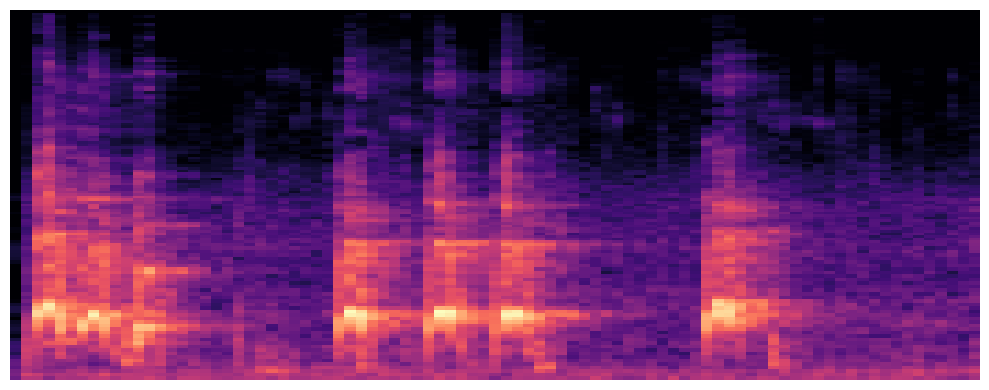

In [ ]:

y, sr = librosa.load("D:/RML/Research_Code/UrbanSound8K/audio/fold1/7383-3-0-0.wav")


mel_spectrogram = librosa.feature.melspectrogram(y=y, sr=sr, n_fft=2048, hop_length=1024, n_mels=128)

# Convert to decibels (log scale)
mel_spectrogram_db = librosa.power_to_db(mel_spectrogram, ref=np.max)


plt.figure(figsize=(10, 4))
librosa.display.specshow(mel_spectrogram_db, sr=sr, x_axis='time', y_axis='mel')
plt.axis('off')
plt.tight_layout()
plt.show()


In [ ]:
import os
import pandas as pd
import librosa
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm

def process_segments(row, input_file_path, foldname, file_name, output_directory):

    y, sr = librosa.load(input_file_path)


    mel_spectrogram = librosa.feature.melspectrogram(y=y, sr=sr, n_fft=2048, hop_length=512, n_mels=128)

    # Convert to decibels (log scale)
    mel_spectrogram_db = librosa.power_to_db(mel_spectrogram, ref=np.max)

    plt.figure(figsize=(10, 4))
    librosa.display.specshow(mel_spectrogram_db, sr=sr, x_axis='time', y_axis='mel')
    plt.axis('off')  
    plt.tight_layout()


    output_subdirectory = os.path.join(output_directory, foldname)
    os.makedirs(output_subdirectory, exist_ok=True)
    output_file_path = os.path.join(output_subdirectory, f'{file_name}.png')
    plt.savefig(output_file_path, bbox_inches='tight', pad_inches=0)  # Remove padding
    plt.close()


    row['slice_file_name'] = f'{file_name}.png'


In [ ]:

new_metadata = pd.DataFrame(columns=metadata.columns)

# Iterate over rows of metadata and process audio segments
for index_num, row in tqdm(metadata.iterrows()):
    file_name = os.path.splitext(row["slice_file_name"])[0] 
    file_path = os.path.join(os.path.abspath(audio_dataset_path), 'fold' + str(row["fold"]), str(row["slice_file_name"]))
    process_segments(row, file_path, 'fold' + str(row["fold"]), file_name, "D:/RML/Research_Code/melspectrogram8k25")
    new_metadata = new_metadata.append(row, ignore_index=True)

0it [00:00, ?it/s]C:\Users\KIIT\AppData\Local\Temp\ipykernel_17304\77700187.py:9: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  new_metadata = new_metadata.append(row, ignore_index=True)
3555it [09:15,  5.98it/s]C:\Users\KIIT\anaconda3\lib\site-packages\librosa\core\spectrum.py:257: UserWarning: n_fft=2048 is too large for input signal of length=1323
  warnings.warn(
8326it [30:29,  3.98it/s]C:\Users\KIIT\anaconda3\lib\site-packages\librosa\core\spectrum.py:257: UserWarning: n_fft=2048 is too large for input signal of length=1103
  warnings.warn(
8329it [30:30,  5.56it/s]C:\Users\KIIT\anaconda3\lib\site-packages\librosa\core\spectrum.py:257: UserWarning: n_fft=2048 is too large for input signal of length=1523
  warnings.warn(
8732it [32:36,  4.46it/s]


In [5]:
# # Save the new metadata DataFrame to a CSV file
# new_csv_file_path = os.path.join("D:/RML/Research_Code/melspectrogram8k")
# new_metadata.to_csv(new_csv_file_path, index=False)


In [7]:
csv_filename = "metadata.csv"
# Save the new metadata DataFrame to a CSV file
new_csv_file_path = os.path.join("D:/RML/Research_Code/melspectrogram8k25", csv_filename)
new_metadata.to_csv(new_csv_file_path, index=False)

In [ ]:
import pandas as pd


df = pd.read_csv("D:/RML/Research_Code/melspectrogram8k25/metadata.csv")


In [9]:
df.head(10)

,slice_file_name,fsID,start,end,salience,fold,classID,class
0,100032-3-0-0.png,100032,0.000000,0.317551,1,5,3,dog_bark
1,100263-2-0-117.png,100263,58.500000,62.500000,1,5,2,children_playing
2,100263-2-0-121.png,100263,60.500000,64.500000,1,5,2,children_playing
3,100263-2-0-126.png,100263,63.000000,67.000000,1,5,2,children_playing
4,100263-2-0-137.png,100263,68.500000,72.500000,1,5,2,children_playing
5,100263-2-0-143.png,100263,71.500000,75.500000,1,5,2,children_playing
6,100263-2-0-161.png,100263,80.500000,84.500000,1,5,2,children_playing
7,100263-2-0-3.png,100263,1.500000,5.500000,1,5,2,children_playing
8,100263-2-0-36.png,100263,18.000000,22.000000,1,5,2,children_playing
9,100648-1-0-0.png,100648,4.823402,5.471927,2,10,1,car_horn


In [10]:
new_metadata

,slice_file_name,fsID,start,end,salience,fold,classID,class
0,100032-3-0-0.png,100032,0.000000,0.317551,1,5,3,dog_bark
1,100263-2-0-117.png,100263,58.500000,62.500000,1,5,2,children_playing
2,100263-2-0-121.png,100263,60.500000,64.500000,1,5,2,children_playing
3,100263-2-0-126.png,100263,63.000000,67.000000,1,5,2,children_playing
4,100263-2-0-137.png,100263,68.500000,72.500000,1,5,2,children_playing
...,...,...,...,...,...,...,...,...
8727,99812-1-2-0.png,99812,159.522205,163.522205,2,7,1,car_horn
8728,99812-1-3-0.png,99812,181.142431,183.284976,2,7,1,car_horn
8729,99812-1-4-0.png,99812,242.691902,246.197885,2,7,1,car_horn
8730,99812-1-5-0.png,99812,253.209850,255.741948,2,7,1,car_horn


In [ ]:
import os


directory_path = "D:/RML/Research_Code/melspectrogram8k25"

folder_file_count = {}


for folder_name in os.listdir(directory_path):
    folder_path = os.path.join(directory_path, folder_name)
    if os.path.isdir(folder_path):
        file_count = len([file for file in os.listdir(folder_path) if os.path.isfile(os.path.join(folder_path, file))])
        folder_file_count[folder_name] = file_count

total=0
for folder_name, count in folder_file_count.items():
    total+=count
    print(f"Folder '{folder_name}' contains {count} files.")
print(total)  


Folder 'fold1' contains 873 files.
Folder 'fold10' contains 837 files.
Folder 'fold2' contains 888 files.
Folder 'fold3' contains 925 files.
Folder 'fold4' contains 990 files.
Folder 'fold5' contains 936 files.
Folder 'fold6' contains 823 files.
Folder 'fold7' contains 838 files.
Folder 'fold8' contains 806 files.
Folder 'fold9' contains 816 files.
8732


In [ ]:
import os


directory_path = 'D:/RML/Research_Code/UrbanSound8K/audio/'


folder_file_count = {}


for folder_name in os.listdir(directory_path):
    folder_path = os.path.join(directory_path, folder_name)
    if os.path.isdir(folder_path):

        file_count = len([file for file in os.listdir(folder_path) if os.path.isfile(os.path.join(folder_path, file))])
        folder_file_count[folder_name] = file_count


total=0
for folder_name, count in folder_file_count.items():
    total+=count
    print(f"Folder '{folder_name}' contains {count-1} files.")
print(total-10)    


Folder 'fold1' contains 873 files.
Folder 'fold10' contains 837 files.
Folder 'fold2' contains 888 files.
Folder 'fold3' contains 925 files.
Folder 'fold4' contains 990 files.
Folder 'fold5' contains 936 files.
Folder 'fold6' contains 823 files.
Folder 'fold7' contains 838 files.
Folder 'fold8' contains 806 files.
Folder 'fold9' contains 816 files.
8732


In [13]:
metadata.head()

,slice_file_name,fsID,start,end,salience,fold,classID,class
0,100032-3-0-0.wav,100032,0.0,0.317551,1,5,3,dog_bark
1,100263-2-0-117.wav,100263,58.5,62.500000,1,5,2,children_playing
2,100263-2-0-121.wav,100263,60.5,64.500000,1,5,2,children_playing
3,100263-2-0-126.wav,100263,63.0,67.000000,1,5,2,children_playing
4,100263-2-0-137.wav,100263,68.5,72.500000,1,5,2,children_playing


In [ ]:
import os
import numpy as np
import librosa

def process_segments_for_npy(row, input_file_path, foldname, file_name, output_directory, target_duration=4):

    y, sr = librosa.load(input_file_path)

    target_frames = int(sr * target_duration / 512)

    mel_spectrogram = librosa.feature.melspectrogram(y=y, sr=sr, n_fft=2048, hop_length=512, n_mels=128)

    # Convert to decibels (log scale)
    mel_spectrogram_db = librosa.power_to_db(mel_spectrogram, ref=np.max)

    # Pad or truncate the mel spectrogram to match the target duration
    current_frames = mel_spectrogram_db.shape[1]
    if current_frames < target_frames:
        pad_width = target_frames - current_frames
        mel_spectrogram_db = np.pad(mel_spectrogram_db, ((0, 0), (0, pad_width)), mode='constant', constant_values=-80)
    elif current_frames > target_frames:
        mel_spectrogram_db = mel_spectrogram_db[:, :target_frames]

    output_subdirectory = os.path.join(output_directory, foldname)
    os.makedirs(output_subdirectory, exist_ok=True)
    output_file_path = os.path.join(output_subdirectory, f'{file_name}.npy')
    np.save(output_file_path, mel_spectrogram_db)

    row['slice_file_name'] = f'{file_name}.npy'


In [ ]:

new_metadata = pd.DataFrame(columns=metadata.columns)


for index_num, row in tqdm(metadata.iterrows()):
    file_name = os.path.splitext(row["slice_file_name"])[0]  
    file_path = os.path.join(os.path.abspath(audio_dataset_path), 'fold' + str(row["fold"]), str(row["slice_file_name"]))
    process_segments_for_npy(row, file_path, 'fold' + str(row["fold"]), file_name, "D:/RML/Research_Code/melspectrogram8k25npy")
    new_metadata = new_metadata.append(row, ignore_index=True)

0it [00:00, ?it/s]C:\Users\KIIT\AppData\Local\Temp\ipykernel_17304\192895329.py:9: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  new_metadata = new_metadata.append(row, ignore_index=True)
3555it [05:29, 10.96it/s]C:\Users\KIIT\anaconda3\lib\site-packages\librosa\core\spectrum.py:257: UserWarning: n_fft=2048 is too large for input signal of length=1323
  warnings.warn(
8325it [13:31, 12.97it/s]C:\Users\KIIT\anaconda3\lib\site-packages\librosa\core\spectrum.py:257: UserWarning: n_fft=2048 is too large for input signal of length=1103
  warnings.warn(
8328it [13:32, 16.67it/s]C:\Users\KIIT\anaconda3\lib\site-packages\librosa\core\spectrum.py:257: UserWarning: n_fft=2048 is too large for input signal of length=1523
  warnings.warn(
8732it [14:08, 10.29it/s]


In [ ]:
csv_filename = "metadata.csv"

new_csv_file_path = os.path.join("D:/RML/Research_Code/melspectrogram8k25npy", csv_filename)
new_metadata.to_csv(new_csv_file_path, index=False)

In [ ]:

df = pd.read_csv("D:/RML/Research_Code/melspectrogram8k25/metadata.csv")
df.head()

,slice_file_name,fsID,start,end,salience,fold,classID,class
0,100032-3-0-0.npy,100032,0.0,0.317551,1,5,3,dog_bark
1,100263-2-0-117.npy,100263,58.5,62.500000,1,5,2,children_playing
2,100263-2-0-121.npy,100263,60.5,64.500000,1,5,2,children_playing
3,100263-2-0-126.npy,100263,63.0,67.000000,1,5,2,children_playing
4,100263-2-0-137.npy,100263,68.5,72.500000,1,5,2,children_playing


In [ ]:
y, sr = librosa.load("D:/RML/Research_Code/UrbanSound8K/audio/fold1/7383-3-0-0.wav")


    
mel_spectrogram = librosa.feature.melspectrogram(y=y, sr=sr, n_fft=2048, hop_length=1024, n_mels=128)


mel_spectrogram_db = librosa.power_to_db(mel_spectrogram, ref=np.max)
print(mel_spectrogram_db)

[[-54.42939  -40.237328 -40.32084  ... -48.688095 -50.00245  -43.88492 ]
 [-51.61712  -34.068977 -37.160465 ... -42.576347 -46.481033 -42.12223 ]
 [-53.072838 -41.317436 -46.19484  ... -41.924046 -39.763367 -36.04581 ]
 ...
 [-80.       -80.       -73.30247  ... -80.       -80.       -80.      ]
 [-80.       -80.       -71.90385  ... -80.       -80.       -80.      ]
 [-80.       -80.       -80.       ... -80.       -80.       -80.      ]]


In [64]:
mel_spectrogram_db.shape[0]

128

In [65]:
mel_spectrogram_db.shape[1]

87

In [21]:
output_file_path = os.path.join("D:/RML/Research_Code/melspectrogram8k25", f'{"filenamepap"}.npy')
np.save(output_file_path, mel_spectrogram_db)

In [28]:
loaded_array = np.load("D:/RML/Research_Code/melspectrogram8k25/filenamepap.npy")
loaded_array[0].size

173

In [ ]:
y, sr = librosa.load("D:/RML/Research_Code/UrbanSound8K/audio/fold1/9031-3-2-0.wav")


    
mel_spectrogram = librosa.feature.melspectrogram(y=y, sr=sr, n_fft=2048, hop_length=1024, n_mels=128)


mel_spectrogram_db = librosa.power_to_db(mel_spectrogram, ref=np.max)
print(mel_spectrogram_db.shape[0])
print(mel_spectrogram_db.shape[1])

128
50


In [ ]:
    y, sr = librosa.load("D:/RML/Research_Code/UrbanSound8K/audio/fold1/9031-3-2-0.wav")

    target_frames = int(sr * 4 / 512)


    mel_spectrogram = librosa.feature.melspectrogram(y=y, sr=sr, n_fft=2048, hop_length=512, n_mels=128)


    mel_spectrogram_db = librosa.power_to_db(mel_spectrogram, ref=np.max)


    current_frames = mel_spectrogram_db.shape[1]
    if current_frames < target_frames:

        pad_width = target_frames - current_frames
        mel_spectrogram_db = np.pad(mel_spectrogram_db, ((0, 0), (0, pad_width)), mode='constant', constant_values=-80)
    elif current_frames > target_frames:

        mel_spectrogram_db = mel_spectrogram_db[:, :target_frames]

In [60]:
mel_spectrogram_db.shape[0]

128

In [40]:
sr

22050

In [61]:
mel_spectrogram_db.shape[1]

50

In [62]:
mel_spectrogram_db

array([[ -3.9925566,  -4.428096 ,  -4.48965  , ...,  -4.609356 ,
         -4.6052647,  -3.636156 ],
       [-13.44207  , -37.567    , -45.177814 , ..., -36.77498  ,
        -23.766079 , -18.577494 ],
       [-17.362986 , -46.751347 , -53.514854 , ..., -38.953705 ,
        -25.630249 , -22.855558 ],
       ...,
       [-50.425747 , -36.30258  , -43.75779  , ..., -65.6414   ,
        -70.72257  , -59.48938  ],
       [-52.38506  , -42.82077  , -45.095478 , ..., -69.16337  ,
        -70.791046 , -59.257492 ],
       [-62.135742 , -53.54983  , -52.974224 , ..., -80.       ,
        -80.       , -61.007236 ]], dtype=float32)

In [ ]:
import os
import numpy as np
import librosa

def process_segments(row, input_file_path, foldname, file_name, output_directory, target_duration=4):

    y, sr = librosa.load(input_file_path)


    duration = librosa.get_duration(y=y, sr=sr)

    if duration < target_duration:
        repetitions = int(np.ceil(target_duration / duration))
        
        y = np.tile(y, repetitions)

    if len(y) > target_duration * sr:
        y = y[:target_duration * sr]  
    elif len(y) < target_duration * sr:
        y = np.pad(y, (0, target_duration * sr - len(y)), mode='constant')  

    mel_spectrogram = librosa.feature.melspectrogram(y=y, sr=sr, n_fft=2048, hop_length=512, n_mels=128)

    mel_spectrogram_db = librosa.power_to_db(mel_spectrogram, ref=np.max)


    output_subdirectory = os.path.join(output_directory, foldname)
    os.makedirs(output_subdirectory, exist_ok=True)
    output_file_path = os.path.join(output_subdirectory, f'{file_name}.npy')
    np.save(output_file_path, mel_spectrogram_db)

    row['slice_file_name'] = f'{file_name}.npy'


In [ ]:

    import soundfile as sf
    y, sr = librosa.load("D:/RML/Research_Code/UrbanSound8K/audio/fold1/9031-3-2-0.wav", sr=44100, res_type='kaiser_fast')
    from sklearn.preprocessing import StandardScaler


#     # Ensure consistent length by padding or truncating
#     if mfccs_features.shape[1] < 400:
#         mfccs_features = np.pad(mfccs_features, ((0, 0), (0, 400 - mfccs_features.shape[1])), mode='constant')
#     else:
#         mfccs_features = mfccs_features[:, :400]

    duration = librosa.get_duration(y=y, sr=sr)


    if duration < 4:
        # Calculate the number of times the audio should be repeated
        repetitions = int(np.ceil(4 / duration))
        
        # Repeat the audio
        y = np.tile(y, repetitions)

    # Trim or pad the audio to the target duration
    if len(y) > 4 * sr:
        y = y[:4 * sr]  # Trim excess
    elif len(y) < 4 * sr:
        y = np.pad(y, (0, 4 * sr - len(y)), mode='constant')  
    mfccs_features = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=40)    

    scaler = StandardScaler()
    mfccs_scaled_features = scaler.fit_transform(mfccs_features)
    print(mfccs_features.shape)
#     output_file_path = os.path.join("D:/RML/Research_Code/UrbanSound8K", f'{"pappure"}.wav')
#     sf.write(output_file_path, y, sr)

(40, 345)


In [ ]:
import os
import numpy as np
import librosa

def process_segments(row, input_file_path, foldname, file_name, output_directory, target_duration=4):

    y, sr = librosa.load(input_file_path)

    duration = librosa.get_duration(y=y, sr=sr)

    # Check if the duration is less than the target duration
    if duration < target_duration:
        # Calculate the number of times the audio should be repeated
        repetitions = int(np.ceil(target_duration / duration))
        
        # Repeat the audio
        y = np.tile(y, repetitions)

    # Trim or pad the audio to the target duration
    if len(y) > target_duration * sr:
        y = y[:target_duration * sr]  # Trim excess
    elif len(y) < target_duration * sr:
        y = np.pad(y, (0, target_duration * sr - len(y)), mode='constant')  # Pad with zeros

    # Save the audio as .wav file
    output_subdirectory = os.path.join(output_directory, foldname)
    os.makedirs(output_subdirectory, exist_ok=True)
    output_file_path = os.path.join(output_subdirectory, f'{file_name}.wav')
    librosa.output.write_wav(output_file_path, y, sr)


    row['slice_file_name'] = f'{file_name}.wav'
